## Recreating experiment script

In [61]:
seed = 10

HETERO_SIGMA_RANGE = (.5, 5.)
VAR_MIN = .1
VAR_MAX = 10.
# VAR_HET = np.logspace(np.log10(VAR_MIN), np.log10(VAR_MAX), 5)

SAVE = True
LOAD = False
# PATH = str(ROOT / "results" / "nonneg_colide" / ("samples_smoke" if SMOKE_TEST else "samples")) + os.sep
PATH = "results/nonneg_colide/variances/"


In [ ]:
# import numpy as np
# np.logspace(np.log10(5),np.log10(10),7).round(2)


array([ 5.  ,  5.61,  6.3 ,  7.07,  7.94,  8.91, 10.  ])

In [62]:
import os, sys
import pandas as pd
from pathlib import Path

# ROOT = Path(__file__).resolve().parents[2]
ROOT = '.'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

import random
import signal
from datetime import datetime
from time import perf_counter

import matplotlib
# if __name__ == "__main__":
#     matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed
from sklearn.metrics import f1_score
import warnings

# Methods without Sigma leave NaN columns in err_sig; silence the nan-aggregation warnings.
for _msg in ("All-NaN slice encountered", "Mean of empty slice", "Degrees of freedom <= 0 for slice"):
    warnings.filterwarnings("ignore", message=_msg, category=RuntimeWarning)

import utils
from model import MetMulDagma, MetMulColide

from baselines.colide import colide_ev, colide_nv
from baselines.dagma_linear import DAGMA_linear

SEED = seed
N_CPUS = max(1, int(os.environ.get("N_CPUS", os.cpu_count() or 1)))
JOBLIB_VERBOSE = max(0, int(os.environ.get("JOBLIB_VERBOSE", 5)))
SELECTED_SCENARIOS = {
    scenario.strip()
    for scenario in os.environ.get("SCENARIOS", "").split(",")
    if scenario.strip()
}
SMOKE_TEST = os.environ.get("SMOKE_TEST", "0") not in ("", "0", "false", "False")
N_DAGS_OVERRIDE = os.environ.get("N_DAGS")

np.random.seed(SEED)
random.seed(SEED)  # networkx graph generators use python's random module
os.makedirs(PATH, exist_ok=True)

def log_status(message):
    timestamp = datetime.now().isoformat(timespec="seconds")
    print(f"[{timestamp} pid={os.getpid()}] {message}", flush=True)


def _handle_termination(signum, frame):
    raise KeyboardInterrupt(f"Received signal {signum}; stopping experiments")


signal.signal(signal.SIGTERM, _handle_termination)


def get_lamb_value(n_nodes, n_samples, times=1):
    return np.sqrt(np.log(n_nodes) / n_samples) * times


def seed_task(g, i=0):
    """
    Seed the numpy and python RNGs for DAG `g` and x-value index `i` inside the worker.
    Module-level seeds are re-executed by every joblib worker that imports this module,
    which made all workers generate the same DAG; per-task seeds give independent and
    reproducible data regardless of the worker assignment. They also neutralize the
    baselines that reset the global numpy RNG in their constructor (colide/dagma seed=0).
    """
    seed = (SEED * 1_000_003 + g * 1_009 + i) % (2 ** 32)
    np.random.seed(seed)
    random.seed(seed)

# ---------------------------------------------------------------------------
# Metrics
# ---------------------------------------------------------------------------
METRIC_NAMES = ("shd", "tpr", "fdr", "fscore", "err", "rel_err", "err_sig", "rel_err_sig",
                "acyc", "runtime", "dag_count")


def compute_sigma_errors(sigma_true, sigma_est):
    """
    Errors of the estimated noise std. `sigma_est` may be a scalar (EV methods) or a
    vector (NV methods); it is broadcast to the N nodes. `err_sig` normalizes both
    vectors before comparing them (same scale-invariant criterion as the Frobenius
    error of W), `rel_err_sig` is the plain relative squared error.
    """
    sigma_true = np.asarray(sigma_true, dtype=float).ravel()
    sigma_est = np.broadcast_to(np.asarray(sigma_est, dtype=float).ravel(), sigma_true.shape)
    if not np.all(np.isfinite(sigma_est)):
        return np.nan, np.nan
    err_sig = utils.compute_norm_sq_err(sigma_true, sigma_est)
    rel_err_sig = np.linalg.norm(sigma_true - sigma_est) ** 2 / np.linalg.norm(sigma_true) ** 2
    return err_sig, rel_err_sig


def fit_model(exp, X, args):
    """Fit one method and return (model, W_est, Sigma_est or None, runtime)."""
    model = exp["model"](**exp["init"]) if "init" in exp else exp["model"]()
    t_init = perf_counter()
    out = model.fit(X, **args)
    runtime = perf_counter() - t_init

    W_est = model.W_est
    Sigma_est = None
    if exp.get("sigma", False):
        if isinstance(out, tuple) and len(out) == 2:
            Sigma_est = out[1]
        elif hasattr(model, "sig_est"):
            Sigma_est = model.sig_est
        elif hasattr(model, "Sigma"):
            Sigma_est = model.Sigma
    return model, W_est, Sigma_est, runtime


def run_var_exp(g, data_p, var_ratios, exps, var_type:str="lin", node_ord_type:str="rand", thr=.2, verb=False):
    assert var_type in [None, 'lin', 'log'], f"Invalid var_type {var_type}."
    assert node_ord_type in [None, "rand", "order", "reverse"], f"Invalid node ordering {node_ord_type}."

    if var_type is None:
        var_type = 'lin'
    if node_ord_type is None:
        node_ord_type = "rand"
    
    node_order = np.arange(data_p["n_nodes"])
    if node_ord_type=='reverse':
        node_order = np.flip(node_order)
    permute = node_ord_type=='rand'

    metrics = {name: np.zeros((len(var_ratios), len(exps))) for name in METRIC_NAMES}
    metrics["err_sig"][:] = np.nan
    metrics["rel_err_sig"][:] = np.nan

    var_base = np.broadcast_to(np.asarray(data_p["var"], dtype=float), data_p["n_nodes"])
    if var_type=='lin':
        var_het = np.linspace(VAR_MIN, VAR_MAX, data_p["n_nodes"])
    else:
        var_het = np.logspace(np.log10(VAR_MIN), np.log10(VAR_MAX), data_p["n_nodes"])
    # node_order = np.random.permutation(data_p["n_nodes"])
    # node_order = np.arange(data_p["n_nodes"])
    node_order = np.arange(data_p["n_nodes"])
    # sigma_true = np.sqrt(np.broadcast_to(np.asarray(data_p["var"], dtype=float), data_p["n_nodes"]))

    for i, ratio in enumerate(var_ratios):
        if g % N_CPUS == 0:
            log_status(f"Graph: {g + 1}, ratio diff.: {ratio}")

        var = var_base.copy()
        num_diff = round( data_p["n_nodes"] * ratio )
        idx = node_order[:num_diff]
        var[idx] = var_het[idx]
        sigma_true = np.sqrt(np.broadcast_to(np.asarray(var, dtype=float), len(var)))

        seed_task(g, i)
        data_p_aux = data_p.copy()
        # data_p_aux["n_samples"] = n_samples
        data_p_aux["var"] = var
        data_p_aux["permute"] = permute

        W_true, _, X = utils.simulate_sem(**data_p_aux)
        X_std = utils.standarize(X)
        W_true_bin = utils.to_bin(W_true, thr)
        norm_W_true = np.linalg.norm(W_true)

        for j, exp in enumerate(exps):
            X_aux = X_std if exp.get("standarize", False) else X

            arg_aux = exp["args"].copy()
            if exp.get("adapt_lamb", False):
                if "lamb" in arg_aux:
                    arg_aux["lamb"] = get_lamb_value(data_p["n_nodes"], data_p["n_samples"], arg_aux["lamb"])
                elif "lambda1" in arg_aux:
                    arg_aux["lambda1"] = get_lamb_value(data_p["n_nodes"], data_p["n_samples"], arg_aux["lambda1"])

            try:
                model, W_est, Sigma_est, runtime = fit_model(exp, X_aux, arg_aux)
            except Exception as exc:
                raise RuntimeError(
                    f"DAG {g} ratio diff.={ratio} method={exp['leg']} failed: "
                    f"{type(exc).__name__}: {exc}"
                ) from exc

            if np.isnan(W_est).any():
                W_est = np.zeros_like(W_est)
                W_est_bin = np.zeros_like(W_est)
            else:
                W_est_bin = utils.to_bin(W_est, thr)

            metrics["shd"][i, j], metrics["tpr"][i, j], metrics["fdr"][i, j] = \
                utils.count_accuracy(W_true_bin, W_est_bin)
            metrics["fscore"][i, j] = f1_score(W_true_bin.flatten(), W_est_bin.flatten())
            metrics["err"][i, j] = utils.compute_norm_sq_err(W_true, W_est, norm_W_true)
            metrics["rel_err"][i, j] = np.linalg.norm(W_true - W_est, "fro") ** 2 / norm_W_true ** 2
            if Sigma_est is not None:
                metrics["err_sig"][i, j], metrics["rel_err_sig"][i, j] = \
                    compute_sigma_errors(sigma_true, Sigma_est)
            metrics["acyc"][i, j] = model.dagness(W_est) if hasattr(model, "dagness") else 1
            metrics["runtime"][i, j] = runtime
            metrics["dag_count"][i, j] += 1 if utils.is_dag(W_est_bin) else 0

            if verb and (g % N_CPUS == 0):
                sig_text = (f"  -  err_sig: {metrics['err_sig'][i, j]:.4f}"
                            if Sigma_est is not None else "")
                log_status(
                    f"\t-{exp['leg']}: shd {metrics['shd'][i, j]}  -  err: {metrics['err'][i, j]:.4f}"
                    f"{sig_text}  -  time: {runtime:.2f}"
                )

    return tuple(metrics[name] for name in METRIC_NAMES)


# ---------------------------------------------------------------------------
# Saving / loading
# ---------------------------------------------------------------------------
def var_results_prefix(scenario_name):
    return f"{PATH}var_{scenario_name}"

def save_var_results(file_prefix, metrics, exps, var_ratios, scenario_name):
    metrics = dict(zip(METRIC_NAMES, metrics))
    np.savez(file_prefix, exps=exps, xvals=var_ratios, scenario=scenario_name, **metrics)
    log_status(f"SAVED in file: {file_prefix}.npz")

    def save_stats(metric, tag, prctiles=True):
        data = metrics[metric]
        utils.data_to_csv(f"{file_prefix}_{tag}_mean.csv", exps, var_ratios, np.nanmean(data, axis=0))
        utils.data_to_csv(f"{file_prefix}_{tag}_std.csv", exps, var_ratios, np.nanstd(data, axis=0))
        if prctiles:
            utils.data_to_csv(f"{file_prefix}_{tag}_med.csv", exps, var_ratios, np.nanmedian(data, axis=0))
            utils.data_to_csv(f"{file_prefix}_{tag}_prctile25.csv", exps, var_ratios,
                              np.nanpercentile(data, 25, axis=0))
            utils.data_to_csv(f"{file_prefix}_{tag}_prctile75.csv", exps, var_ratios,
                              np.nanpercentile(data, 75, axis=0))

def load_var_results(scenario_name):
    file_name = f"{var_results_prefix(scenario_name)}.npz"
    data = np.load(file_name, allow_pickle=True)
    log_status(f"Loaded var results from {file_name}")
    metrics = tuple(data[name] for name in METRIC_NAMES)
    return (*metrics, data["exps"].tolist(), data["xvals"])


# def run_var_exp(g, data_p, var_ratios, exps, var_type:str="lin", node_ord_type:str="rand", thr=.2, verb=False):
def run_or_load_var_results(data_p, var_ratios, exps, n_dags, scenario_name, thr=.2, verb=False):
    if SELECTED_SCENARIOS and scenario_name not in SELECTED_SCENARIOS:
        log_status(f"SKIP scenario={scenario_name} selected={sorted(SELECTED_SCENARIOS)}")
        return None

    if LOAD:
        return load_var_results(scenario_name)

    var = np.asarray(data_p["var"], dtype=float)
    var_text = f"{var:.3g}" if var.ndim == 0 else f"hetero[{var.min():.3g},{var.max():.3g}] mean={var.mean():.3g}"
    n_jobs = max(1, min(N_CPUS, n_dags))
    log_status(
        f"START scenario={scenario_name} nodes={data_p['n_nodes']} edges={data_p['edges']} "
        f"var={var_text} dags={n_dags} ratios={list(var_ratios)} "
        f"methods={[exp['leg'] for exp in exps]} workers={n_jobs}"
    )

    t_init = perf_counter()
    parallel = Parallel(n_jobs=n_jobs, verbose=JOBLIB_VERBOSE)
    try:
        results = parallel(
            # delayed(run_var_exp)(g, data_p, var_ratios, exps, thr, verb)
            delayed(run_var_exp)(g, data_p, var_ratios, exps, var_type, node_ord_type, thr, verb)
            for g in range(n_dags)
        )
    except (KeyboardInterrupt, SystemExit):
        backend = getattr(parallel, "_backend", None)
        if backend is not None and hasattr(backend, "terminate"):
            backend.terminate()
        raise
    finally:
        backend = getattr(parallel, "_backend", None)
        if backend is not None and hasattr(backend, "terminate"):
            backend.terminate()

    log_status(f"DONE scenario={scenario_name} elapsed_minutes={(perf_counter() - t_init) / 60:.3f}")

    metrics = tuple(np.asarray(metric) for metric in zip(*results))
    if SAVE:
        save_var_results(var_results_prefix(scenario_name), metrics, exps, var_ratios, scenario_name)

    return (*metrics, exps, var_ratios)


# ---------------------------------------------------------------------------
# Experiments
# ---------------------------------------------------------------------------
def build_experiments():
    """
    Nonnegative CoLiDE (SCA+Adam, NV and EV) with the hyperparameters of
    nonneg_colide/scripts/preliminary_exp.py; NOMAD, DAGMA and CoLiDE with the
    configuration of synthetic/scripts/number_samples.py. 'sigma': True marks
    the methods that estimate the noise std.
    """
    nn_colide_args = {
        "stepsize": 3e-4,
        "step_type": "fixed",
        "alpha_0": .01,
        "rho_0": .05,
        "s": 1,
        "lamb": .1,
        "iters_in": 30000,
        "iters_out": 10,
        "beta": 2,
        "sca_adam": True,
    }
    colide_args = {"lambda1": .05, "T": 4, "s": [1.0, .9, .8, .7], "warm_iter": 2e4, "max_iter": 7e4, "lr": .0003}

    exps = [
        ### NONNEGATIVE COLIDE ###
        {
            "model": MetMulColide,
            "args": nn_colide_args.copy(),
            "init": {"primal_opt": "sca", "acyclicity": "logdet", "equal_var": False},
            "adapt_lamb": True,
            "standarize": False,
            "sigma": True,
            "fmt": "o-",
            "leg": "NN-CoLiDE-NV",
        },
        {
            "model": MetMulColide,
            "args": nn_colide_args.copy(),
            "init": {"primal_opt": "sca", "acyclicity": "logdet", "equal_var": True},
            "adapt_lamb": True,
            "standarize": False,
            "sigma": True,
            "fmt": "o--",
            "leg": "NN-CoLiDE-EV",
        },
        ### NOMAD (previous paper) ###
        {
            "model": MetMulDagma,
            "args": {
                "stepsize": 5e-3,
                "step_type": "fixed",
                "alpha_0": .1,
                "rho_0": .1,
                "s": 1,
                "lamb": .2,
                "iters_in": 5000,
                "iters_out": 10,
                "beta": 1.5,
            },
            "init": {"primal_opt": "adam", "acyclicity": "logdet"},
            "adapt_lamb": True,
            "standarize": False,
            "sigma": False,
            "fmt": "s-",
            "leg": "NOMAD-adam",
        },
        ### BASELINES ###
        {
            "model": DAGMA_linear,
            "init": {"loss_type": "l2"},
            "args": colide_args.copy(),
            "adapt_lamb": False,
            "standarize": False,
            "sigma": False,
            "fmt": "^-",
            "leg": "DAGMA",
        },
        {
            "model": colide_ev,
            "args": colide_args.copy(),
            "adapt_lamb": False,
            "standarize": False,
            "sigma": True,
            "fmt": "v--",
            "leg": "CoLiDE-EV",
        },
        {
            "model": colide_nv,
            "args": colide_args.copy(),
            "adapt_lamb": False,
            "standarize": False,
            "sigma": True,
            "fmt": "v-",
            "leg": "CoLiDE-NV",
        },
    ]

    if SMOKE_TEST:
        for exp in exps:
            if exp["model"] is MetMulColide or exp["model"] is MetMulDagma:
                exp["args"].update({"iters_in": 200, "iters_out": 2})
            else:
                exp["args"].update({"T": 2, "warm_iter": 100, "max_iter": 200})
    return exps


def build_scenarios(n_nodes=100):
    base = {
        "n_samples": int(1e4),
        "n_nodes": n_nodes,
        "graph_type": "er",
        "edges": 4 * n_nodes,
        "edge_type": "positive",
        "w_range": (.5, 1),
    }
    rng = np.random.default_rng(SEED)
    hetero_var = rng.uniform(low=HETERO_SIGMA_RANGE[0], high=HETERO_SIGMA_RANGE[1], size=n_nodes) ** 2

    return [
        {"name": f"er4_N{n_nodes}_var1", "title": "var = 1", "data_params": {**base, "var": 1}},
        {"name": f"er4_N{n_nodes}_var10", "title": "var = 10", "data_params": {**base, "var": 10}},
        {"name": f"er4_N{n_nodes}_hetero", "title": "heteroscedastic", "data_params": {**base, "var": hetero_var}},
    ]


# ---------------------------------------------------------------------------
# Plots
# ---------------------------------------------------------------------------
def sigma_skip_idx(exps, skip_idx=()):
    """Indices to skip in the Sigma plots: methods without Sigma plus the given ones."""
    return sorted(set(skip_idx) | {i for i, exp in enumerate(exps) if not exp.get("sigma", False)})

def plot_sigma_error(err_sig, exps, var_ratios, skip_idx=(), agg="median", deviation="prctile",
                     alpha=.25, title=None, figsize=(6, 4.5), ylabel="Sigma error (normalized)"):
    """Single panel with the scale-invariant Sigma error of the methods that estimate it."""
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    utils.plot_data(ax, err_sig, exps, var_ratios, "Ratio of nodes", ylabel,
                    sigma_skip_idx(exps, skip_idx), agg=agg, deviation=deviation, alpha=alpha,
                    plot_func="semilogy")
    if title is not None:
        ax.set_title(title)
    fig.tight_layout()
    return fig, ax

def plot_results(metrics, exps, var_ratios, scenario, skip_idx=(), save=True):
    metrics = dict(zip(METRIC_NAMES, metrics))
    prefix = var_results_prefix(scenario["name"])
    skip = list(skip_idx)

    fig, _ = utils.plot_shd_error_pair(
        metrics["shd"], metrics["err"], exps, var_ratios,
        xlabel="Ratio of nodes",
        shd_ylabel="SHD",
        err_ylabel="Fro Error",
        skip_idx=skip,
        alpha=0.25,
        shd_agg="mean",
        shd_deviation="std",
        err_agg="median",
        err_deviation="prctile",
        err_plot_func="semilogy",
        figsize=(10, 5),
        title=scenario["title"],
    )
    if save:
        fig.savefig(f"{prefix}_summary.png", bbox_inches="tight")

    fig, _ = plot_sigma_error(metrics["err_sig"], exps, var_ratios, skip_idx=skip,
                              title=f"{scenario['title']} - Sigma error")
    if save:
        fig.savefig(f"{prefix}_sigma_error.png", bbox_inches="tight")

    for agg in ("mean", "median"):
        utils.plot_all_metrics(metrics["shd"], metrics["tpr"], metrics["fdr"], metrics["fscore"], metrics["err"],
                               metrics["acyc"], metrics["runtime"], metrics["dag_count"], var_ratios, exps,
                               skip_idx=skip, agg=agg)
        if save:
            plt.savefig(f"{prefix}_all_metrics_{agg}.png", bbox_inches="tight")
    if save:
        plt.close("all")



In [63]:
def run_or_load(name, skip=()):
    sc = scenarios[name]
    out = run_or_load_var_results(sc["data_params"], var_ratios, exps, n_dags, sc["name"], thr=thr, verb=verb)
    *metrics, exps_out, xvals = out
    results[name] = {"metrics": dict(zip(METRIC_NAMES, metrics)), "exps": exps_out, "xvals": xvals, "scenario": sc}
    return results[name]


def show_scenario(name, skip=()):
    res = run_or_load(name)
    m, exps_out, xvals, sc = res["metrics"], res["exps"], res["xvals"], res["scenario"]
    skip = list(skip)
    prefix = var_results_prefix(sc["name"])

    # SHD (mean +- std) and Fro error (median, prctiles 25-75)
    fig, _ = utils.plot_shd_error_pair(m["shd"], m["err"], exps_out, xvals, xlabel="Ratio of nodes",
                                       shd_ylabel="SHD", err_ylabel="Fro Error", skip_idx=skip, alpha=.25,
                                       shd_agg="mean", shd_deviation="std", err_agg="median", err_deviation="prctile",
                                       err_plot_func="semilogy", figsize=(10, 5), title=sc["title"])
    if SAVE_FIGS:
        fig.savefig(f"{prefix}_summary.png", bbox_inches="tight")

    # Sigma error (only methods that estimate Sigma)
    fig, _ = plot_sigma_error(m["err_sig"], exps_out, xvals, skip_idx=skip, title=f'{sc["title"]} - Sigma error')
    if SAVE_FIGS:
        fig.savefig(f"{prefix}_sigma_error.png", bbox_inches="tight")

    # Tables at each number of samples
    legs = [e["leg"] for e in exps_out]
    for metric, agg, label in [("shd", np.mean, "SHD (mean)"), ("err", np.median, "Fro error (median)"),
                               ("err_sig", np.nanmedian, "Sigma error (median)"), ("runtime", np.mean, "time (mean, s)")]:
        with np.errstate(all="ignore"):
            table = pd.DataFrame(agg(m[metric], axis=0), index=xvals, columns=legs).rename_axis("ratios")
        print(f"\n{sc['title']} - {label}")
        display(table.round(4))
    return res


def show_all_metrics(name, agg="mean", skip=()):
    m, exps_out, xvals = results[name]["metrics"], results[name]["exps"], results[name]["xvals"]
    utils.plot_all_metrics(m["shd"], m["tpr"], m["fdr"], m["fscore"], m["err"], m["acyc"], m["runtime"],
                           m["dag_count"], xvals, exps_out, skip_idx=list(skip), agg=agg)


In [64]:
SAVE = True
LOAD = False

n_nodes = 70
var_type = "lin"
node_ord_type = "rand"
n_dags = 10
var_ratios = np.array([ .1,.5,.9 ])
thr = .2
verb = True

exps = build_experiments()
scenarios = build_scenarios(n_nodes=n_nodes)
for scenario in scenarios:
    out = run_or_load_var_results(
        scenario["data_params"],
        var_ratios, 
        exps, 
        n_dags, 
        scenario["name"],
        thr=thr,
        verb=verb
    )
    if out is None:
        continue
    *metrics, exps_out, xvals = out
    plot_results(metrics, exps_out, xvals, scenario)


[2026-09-15T17:06:56 pid=1146670] START scenario=er4_N70_var1 nodes=70 edges=280 var=1 dags=10 ratios=[np.float64(0.1), np.float64(0.5), np.float64(0.9)] methods=['NN-CoLiDE-NV', 'NN-CoLiDE-EV', 'NOMAD-adam', 'DAGMA', 'CoLiDE-EV', 'CoLiDE-NV'] workers=10
[2026-09-15T17:06:56 pid=1152856] Graph: 1, ratio diff.: 0.1


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.


[2026-09-15T17:07:05 pid=1152856] 	-NN-CoLiDE-NV: shd 2.0  -  err: 0.0149  -  err_sig: 0.0046  -  time: 8.05
[2026-09-15T17:07:14 pid=1152856] 	-NN-CoLiDE-EV: shd 2.0  -  err: 0.0150  -  err_sig: 0.0138  -  time: 9.61
[2026-09-15T17:07:21 pid=1152856] 	-NOMAD-adam: shd 2.0  -  err: 0.0149  -  time: 7.17
[2026-09-15T17:07:29 pid=1152856] 	-DAGMA: shd 24.0  -  err: 0.0716  -  time: 7.61
[2026-09-15T17:07:39 pid=1152856] 	-CoLiDE-EV: shd 29.0  -  err: 0.0850  -  err_sig: 0.0138  -  time: 9.86
[2026-09-15T17:07:51 pid=1152856] 	-CoLiDE-NV: shd 26.0  -  err: 0.0843  -  err_sig: 0.0193  -  time: 12.19
[2026-09-15T17:07:51 pid=1152856] Graph: 1, ratio diff.: 0.5
[2026-09-15T17:08:09 pid=1152856] 	-NN-CoLiDE-NV: shd 2.0  -  err: 0.0196  -  err_sig: 0.0323  -  time: 17.68
[2026-09-15T17:08:36 pid=1152856] 	-NN-CoLiDE-EV: shd 12.0  -  err: 0.0469  -  err_sig: 0.1159  -  time: 27.02
[2026-09-15T17:08:51 pid=1152856] 	-NOMAD-adam: shd 12.0  -  err: 0.0471  -  time: 15.07
[2026-09-15T17:09:05 pid=1

[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed:  4.6min remaining: 10.8min
[Parallel(n_jobs=10)]: Done   6 out of  10 | elapsed:  5.0min remaining:  3.3min


[2026-09-15T17:12:35 pid=1146670] DONE scenario=er4_N70_var1 elapsed_minutes=5.644
[2026-09-15T17:12:35 pid=1146670] SAVED in file: results/nonneg_colide/variances/var_er4_N70_var1.npz


...

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.


[2026-09-15T17:18:52 pid=1149235] 	-NN-CoLiDE-NV: shd 17.0  -  err: 0.0797  -  err_sig: 0.0593  -  time: 18.25
[2026-09-15T17:19:06 pid=1149235] 	-NN-CoLiDE-EV: shd 22.0  -  err: 0.0967  -  err_sig: 0.2057  -  time: 14.25
[2026-09-15T17:19:17 pid=1149235] 	-NOMAD-adam: shd 24.0  -  err: 0.0919  -  time: 10.74
[2026-09-15T17:19:26 pid=1149235] 	-DAGMA: shd 275.0  -  err: 0.8576  -  time: 9.24
[2026-09-15T17:19:36 pid=1149235] 	-CoLiDE-EV: shd 256.0  -  err: 0.8246  -  err_sig: 0.2057  -  time: 9.54
[2026-09-15T17:19:49 pid=1149235] 	-CoLiDE-NV: shd 289.0  -  err: 0.8584  -  err_sig: 0.3301  -  time: 13.26
[2026-09-15T17:19:49 pid=1149235] Graph: 1, ratio diff.: 0.5
[2026-09-15T17:20:12 pid=1149235] 	-NN-CoLiDE-NV: shd 2.0  -  err: 0.0209  -  err_sig: 0.0111  -  time: 23.10
[2026-09-15T17:20:43 pid=1149235] 	-NN-CoLiDE-EV: shd 8.0  -  err: 0.0386  -  err_sig: 0.2243  -  time: 30.60
[2026-09-15T17:21:07 pid=1149235] 	-NOMAD-adam: shd 10.0  -  err: 0.0428  -  time: 24.09
[2026-09-15T17:21:

[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed:  5.3min remaining: 12.5min
[Parallel(n_jobs=10)]: Done   6 out of  10 | elapsed:  6.0min remaining:  4.0min


[2026-09-15T17:25:20 pid=1146670] DONE scenario=er4_N70_hetero elapsed_minutes=6.763
[2026-09-15T17:25:20 pid=1146670] SAVED in file: results/nonneg_colide/variances/var_er4_N70_hetero.npz


[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:  6.8min finished


In [69]:
SAVE = False
LOAD = True
SAVE_FIGS=  False
# RESULTS_DIR = None

scenarios = {sc["name"]: sc for sc in build_scenarios(n_nodes=n_nodes)}

pd.DataFrame([{"leg": e["leg"], "model": e["model"].__name__, "sigma": e["sigma"], "adapt_lamb": e["adapt_lamb"],
               **e.get("init", {}), **e["args"]} for e in exps]).set_index("leg")

results = {}


[2026-09-15T17:25:54 pid=1146670] Loaded var results from results/nonneg_colide/variances/var_er4_N70_var1.npz

var = 1 - SHD (mean)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
ratios,,,,,,
0.1,1.1,1.8,1.9,33.5,36.4,45.4
0.5,4.7,8.5,7.6,115.7,114.6,94.1
0.9,7.0,11.4,11.5,178.8,160.4,137.3



var = 1 - Fro error (median)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
ratios,,,,,,
0.1,0.0005,0.0019,0.0019,0.1003,0.0935,0.1461
0.5,0.0263,0.0439,0.0436,0.3321,0.3512,0.2946
0.9,0.0320,0.0410,0.0465,0.5987,0.5471,0.4828



var = 1 - Sigma error (median)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
ratios,,,,,,
0.1,0.0001,0.0138,NaN,NaN,0.0138,0.0207
0.5,0.0174,0.1159,NaN,NaN,0.1159,0.0797
0.9,0.0206,0.1323,NaN,NaN,0.1323,0.1075



var = 1 - time (mean, s)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
ratios,,,,,,
0.1,14.0887,18.7172,13.0418,12.6972,13.7183,14.2424
0.5,20.7749,24.0344,14.2439,14.5342,15.6540,16.8793
0.9,20.1110,25.5979,16.5916,13.3970,12.4967,11.6412


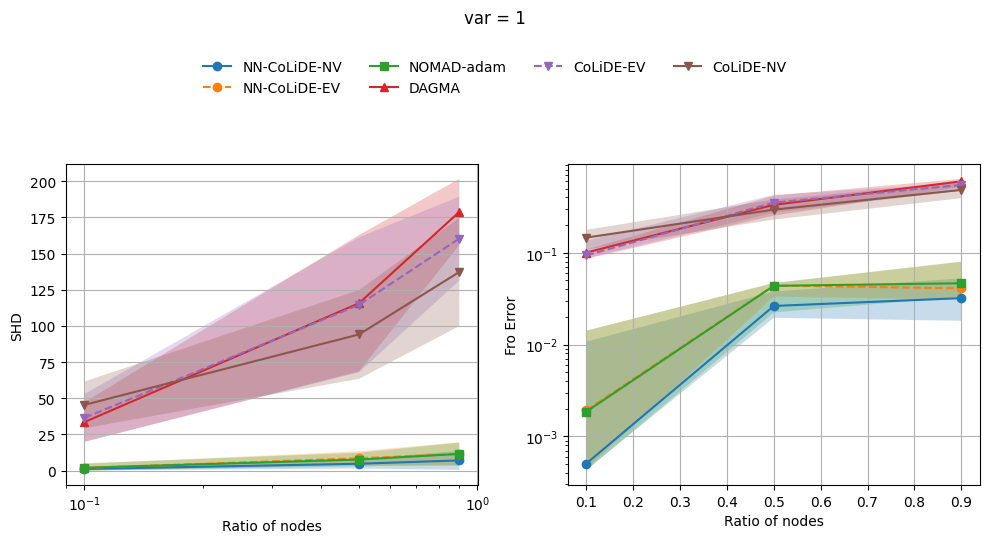

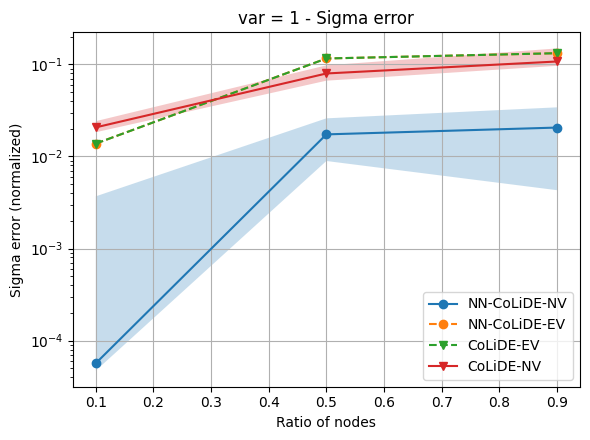

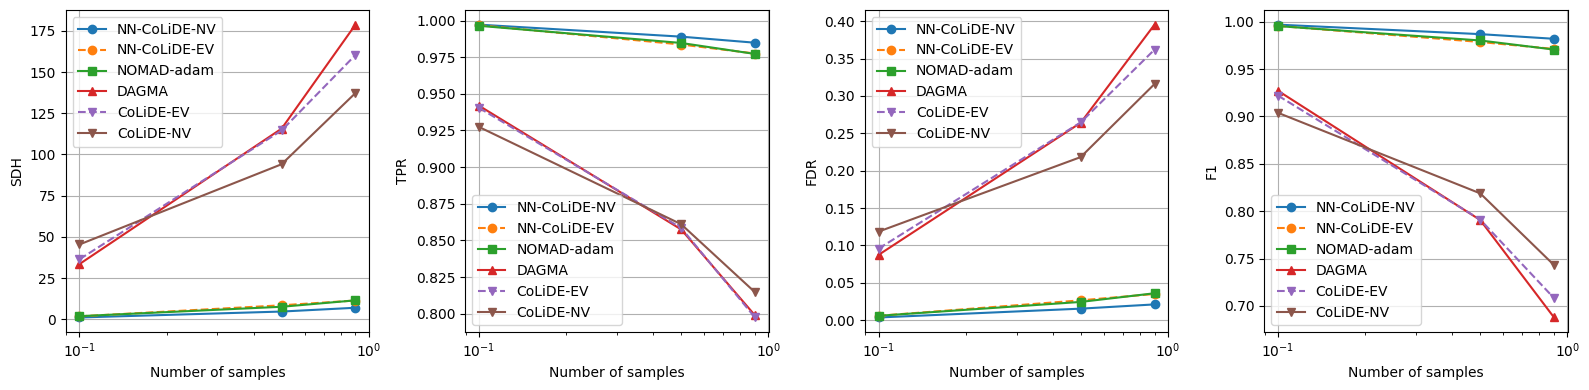

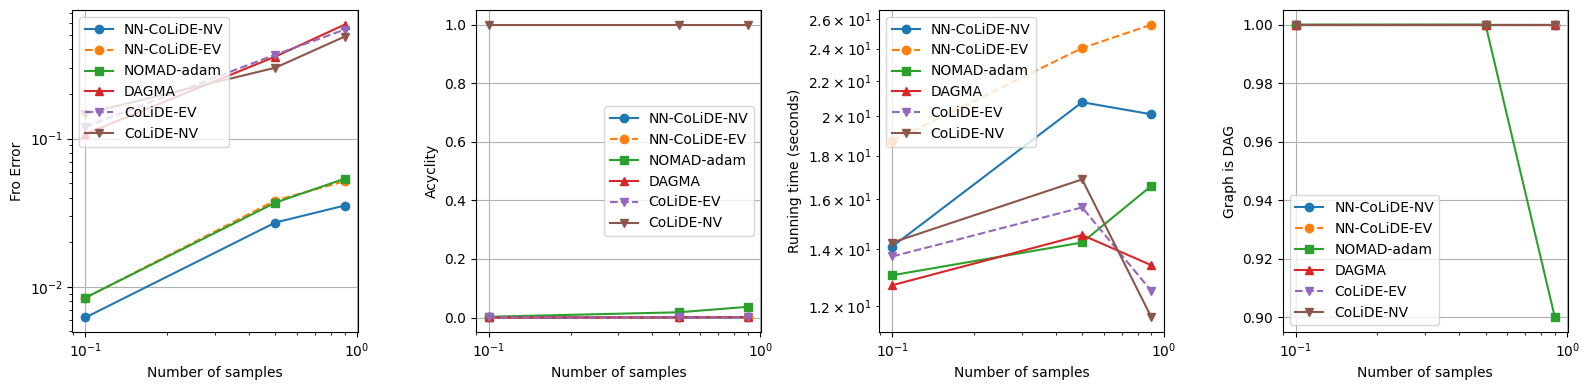

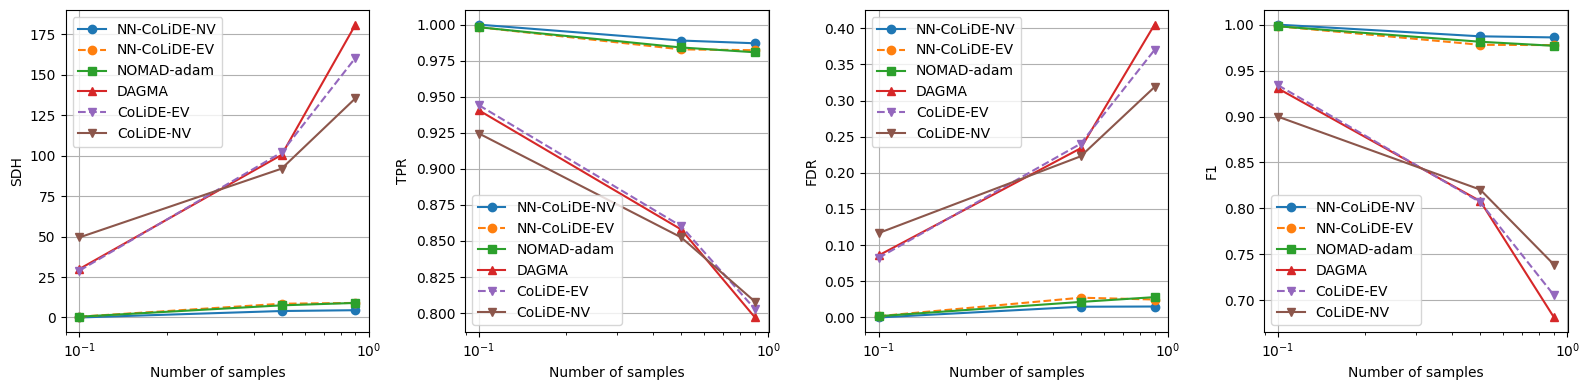

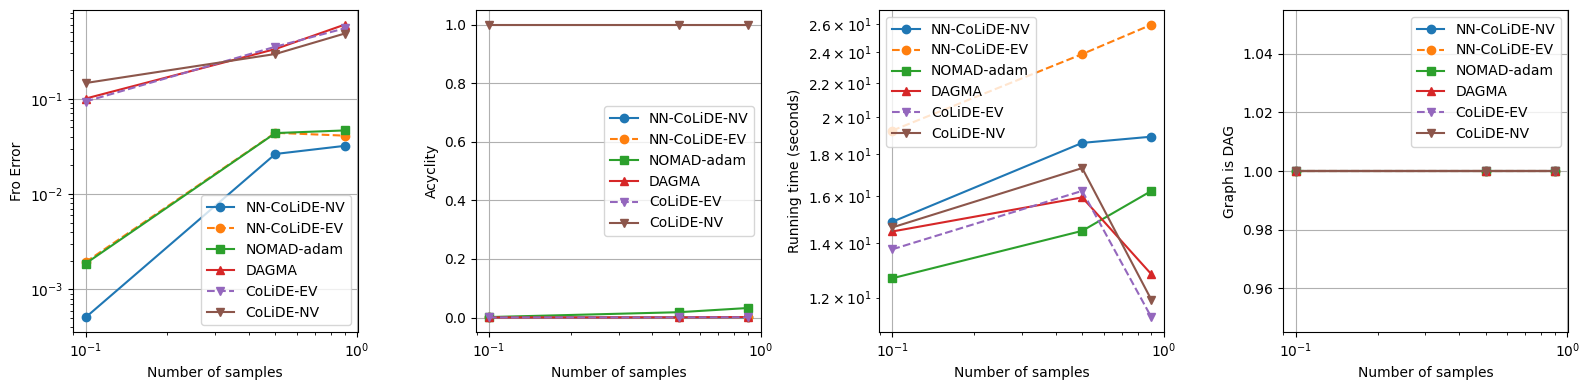

In [70]:
skip = []
res = show_scenario(f"er4_N{n_nodes}_var1", skip=skip)

show_all_metrics(f"er4_N{n_nodes}_var1", agg="mean", skip=skip)
show_all_metrics(f"er4_N{n_nodes}_var1", agg="median", skip=skip)

[2026-09-15T17:25:58 pid=1146670] Loaded var results from results/nonneg_colide/variances/var_er4_N70_var10.npz

var = 10 - SHD (mean)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
ratios,,,,,,
0.1,2.3,4.8,5.4,125.0,102.5,116.8
0.5,7.5,13.5,13.0,211.6,179.4,173.8
0.9,5.3,7.5,7.7,180.9,160.8,134.3



var = 10 - Fro error (median)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
ratios,,,,,,
0.1,0.0162,0.0216,0.0280,0.4379,0.3530,0.4185
0.5,0.0376,0.0567,0.0552,0.6771,0.5904,0.5926
0.9,0.0318,0.0377,0.0375,0.5638,0.5089,0.4752



var = 10 - Sigma error (median)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
ratios,,,,,,
0.1,0.0096,0.0620,NaN,NaN,0.0620,0.0863
0.5,0.0176,0.1355,NaN,NaN,0.1355,0.1213
0.9,0.0159,0.1137,NaN,NaN,0.1137,0.1140



var = 10 - time (mean, s)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
ratios,,,,,,
0.1,22.8536,21.3119,18.5274,15.8706,16.9524,17.6436
0.5,19.6281,25.4537,18.3212,15.7235,18.6387,19.2434
0.9,19.3944,24.7109,13.6298,10.9840,13.0886,11.4537


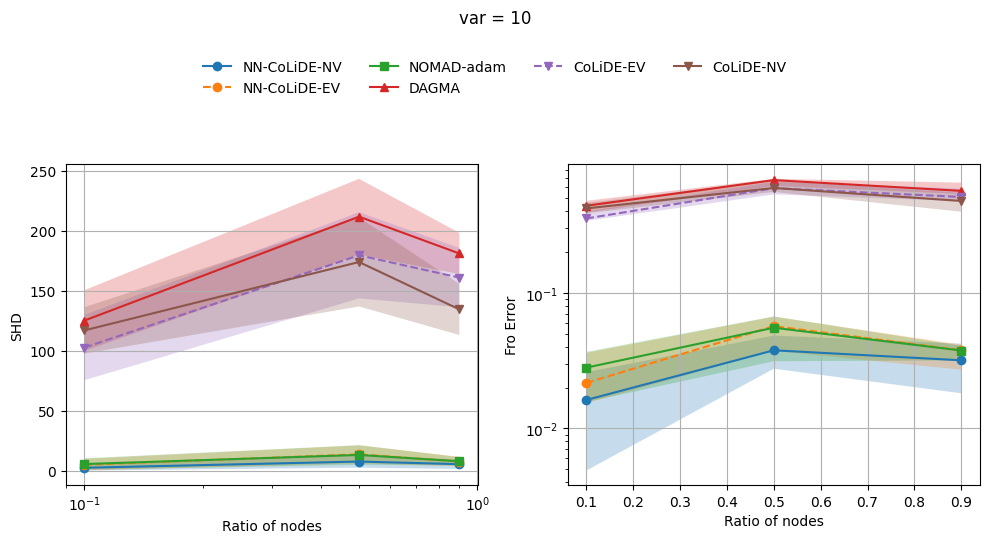

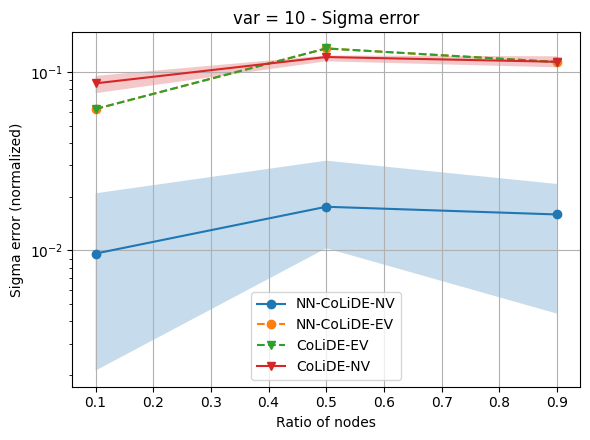

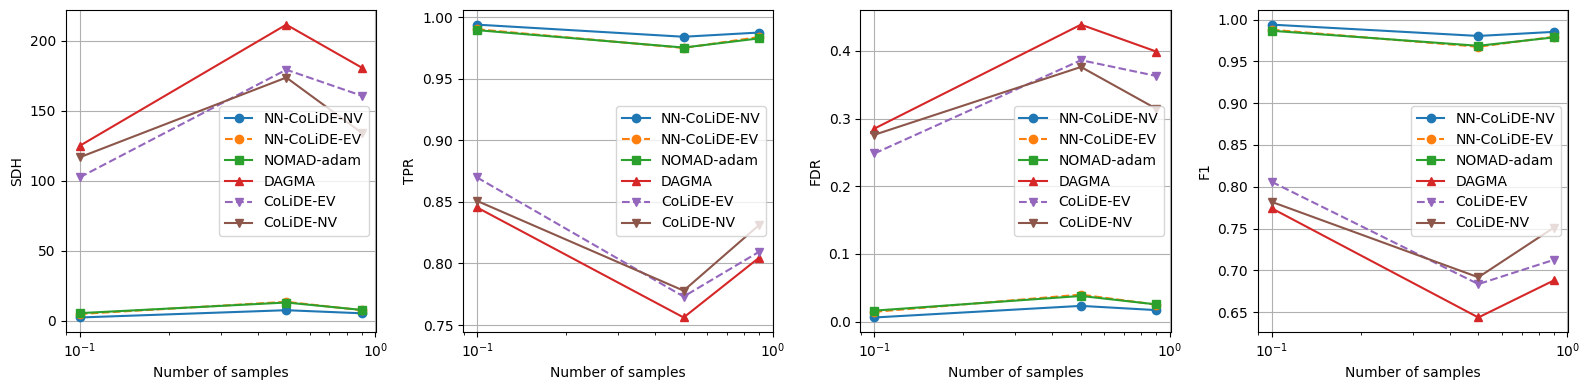

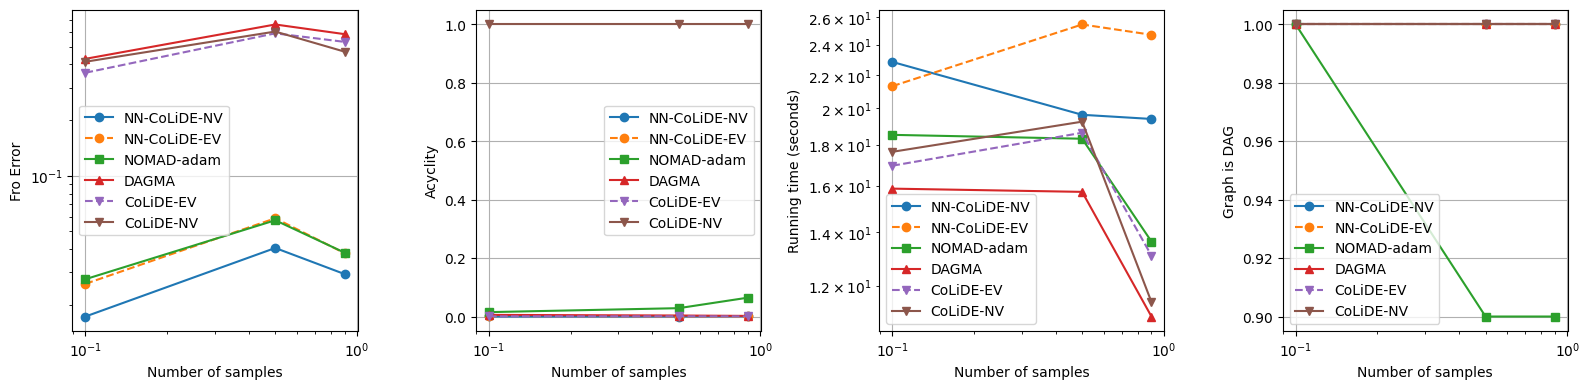

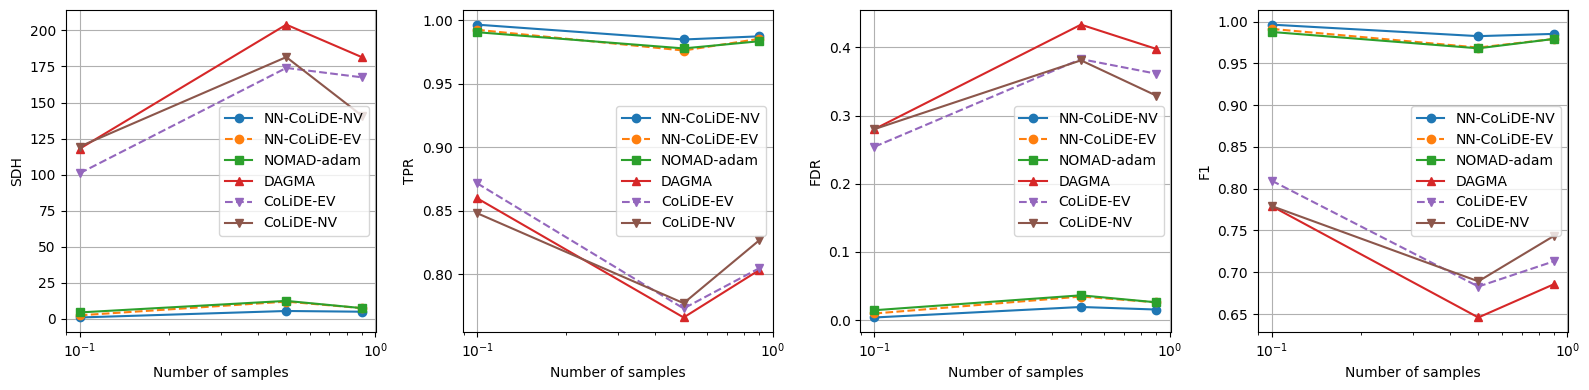

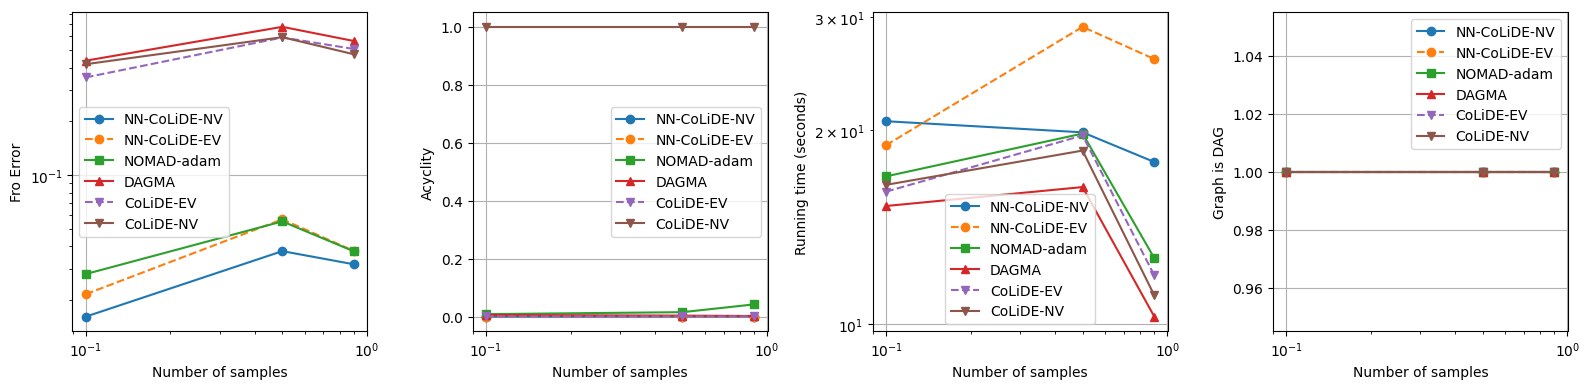

In [71]:
skip = []
res = show_scenario(f"er4_N{n_nodes}_var10", skip=skip)

show_all_metrics(f"er4_N{n_nodes}_var10", agg="mean", skip=skip)
show_all_metrics(f"er4_N{n_nodes}_var10", agg="median", skip=skip)

[2026-09-15T17:26:03 pid=1146670] Loaded var results from results/nonneg_colide/variances/var_er4_N70_hetero.npz

heteroscedastic - SHD (mean)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
ratios,,,,,,
0.1,10.4,18.5,20.7,236.3,205.5,206.7
0.5,10.4,18.3,20.3,246.7,223.2,182.8
0.9,5.4,9.0,8.6,185.4,157.2,139.7



heteroscedastic - Fro error (median)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
ratios,,,,,,
0.1,0.0433,0.0853,0.0755,0.7432,0.7189,0.6816
0.5,0.0576,0.0708,0.0794,0.7747,0.7378,0.6546
0.9,0.0359,0.0418,0.0401,0.5651,0.5158,0.5122



heteroscedastic - Sigma error (median)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
ratios,,,,,,
0.1,0.0421,0.2057,NaN,NaN,0.2057,0.2213
0.5,0.0324,0.2243,NaN,NaN,0.2243,0.2056
0.9,0.0154,0.1328,NaN,NaN,0.1328,0.1430



heteroscedastic - time (mean, s)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
ratios,,,,,,
0.1,30.4666,31.0248,19.6726,15.8863,18.5277,19.4513
0.5,21.0276,27.0557,18.9194,15.7474,19.8202,19.4195
0.9,19.5485,24.1136,12.8411,12.1400,12.4397,11.2668


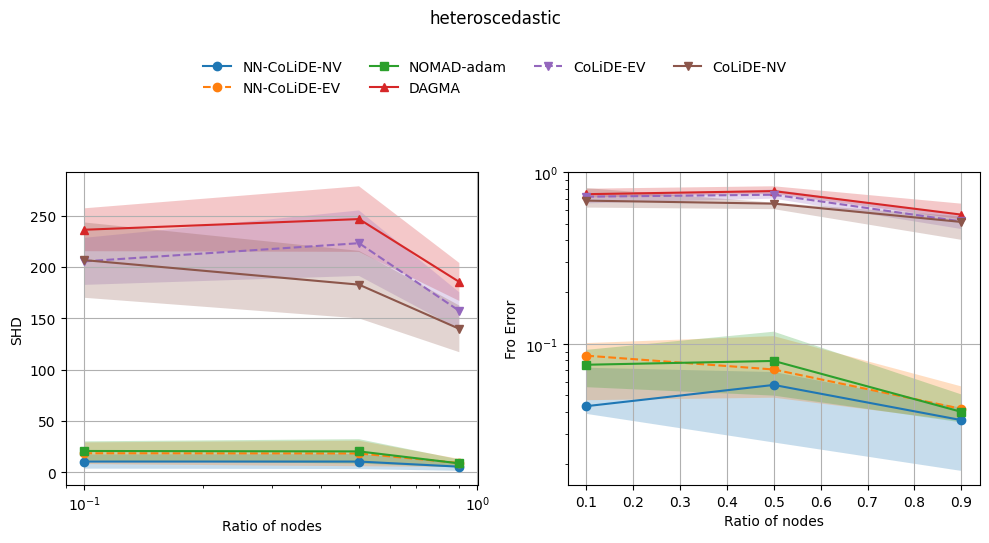

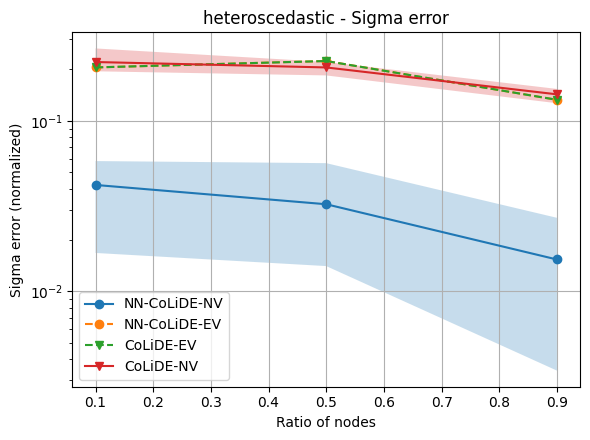

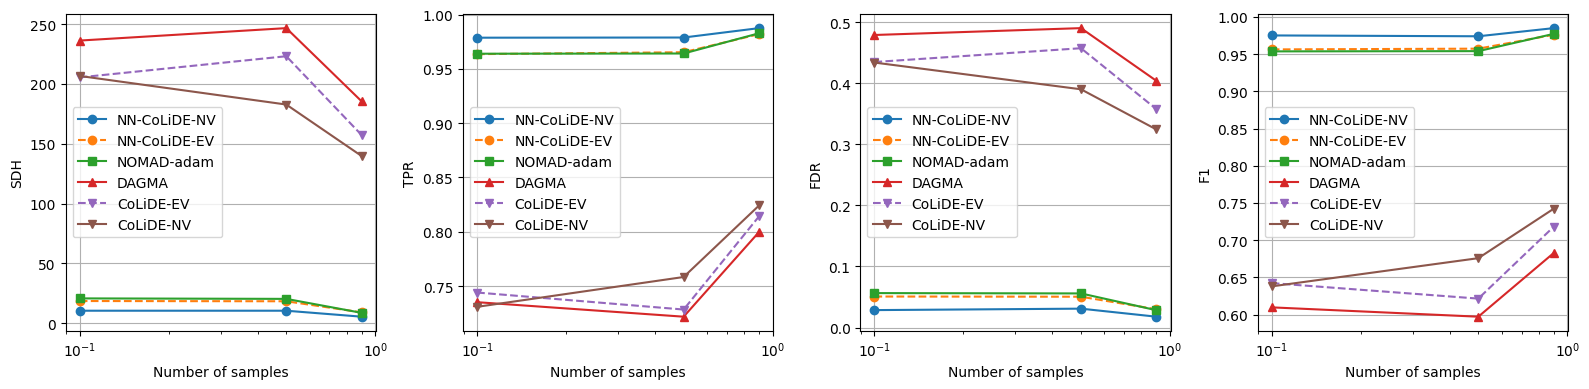

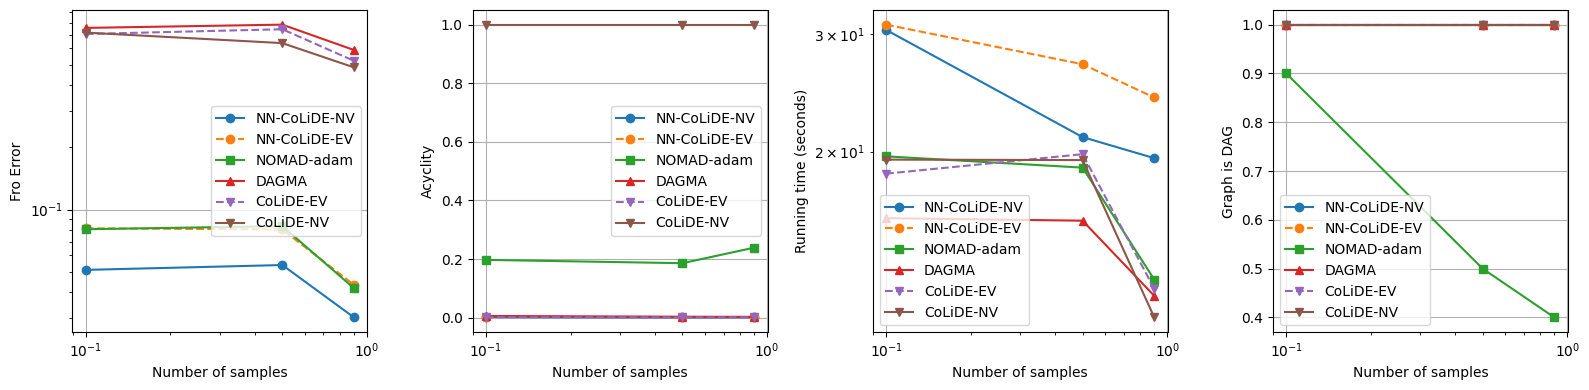

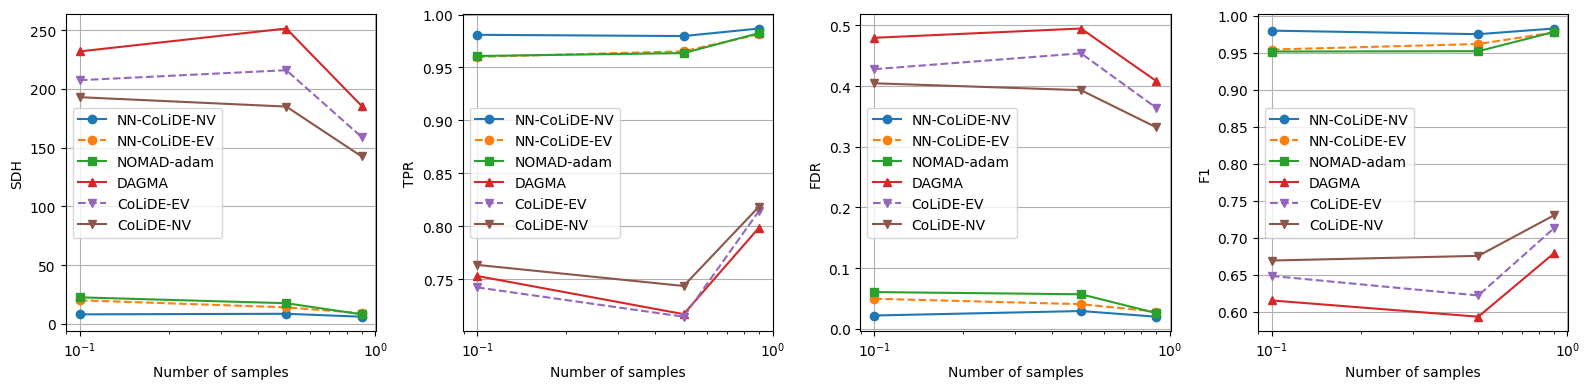

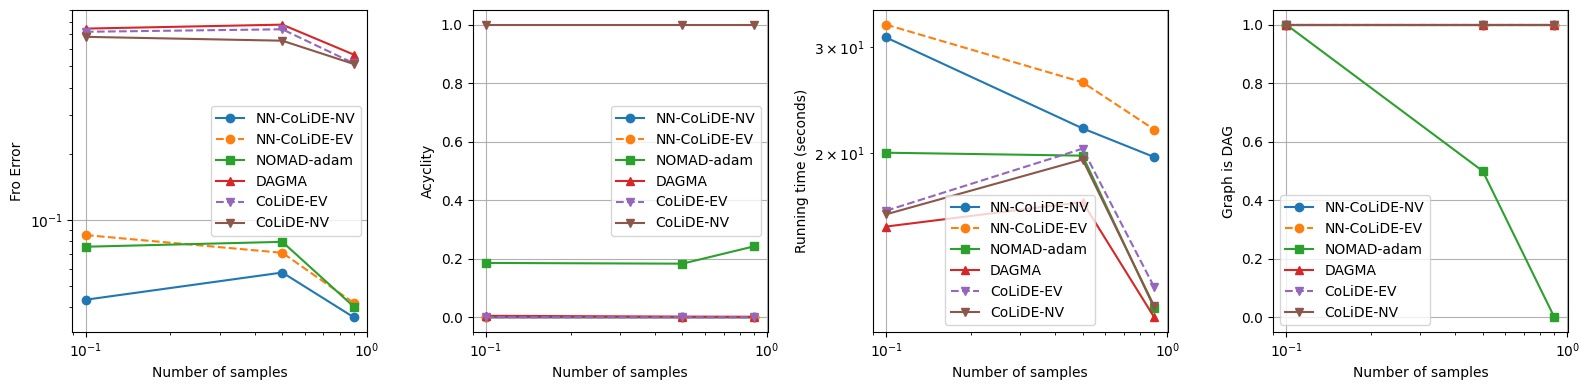

In [72]:
skip = []
res = show_scenario(f"er4_N{n_nodes}_hetero", skip=skip)

show_all_metrics(f"er4_N{n_nodes}_hetero", agg="mean", skip=skip)
show_all_metrics(f"er4_N{n_nodes}_hetero", agg="median", skip=skip)